# 🔎 Hallucination Detector

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/llmops-genai-platform/hallucination-checker/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=llmops-genai-platform/hallucination-checker/demo.ipynb)

**Flag the claims your RAG answer makes that the retrieved context never supported.**

Your RAG pipeline retrieves context, the LLM writes an answer - and sometimes it states a wrong number, an extra "fact", or a fabricated entity. This notebook scores **groundedness** per claim and flags the unsupported ones before they reach a user.

**What we cover**
1. The setup: RAG (context, answer) pairs with planted errors
2. Split an answer into claims
3. Score support: lexical overlap + a number check
4. Flag unsupported claims
5. Batch results + groundedness chart
6. The honest limitation (why you still need a judge model)
7. Try your own

## 1. Setup

Four RAG answers. One is fully grounded; the others each contain a planted problem: a wrong number, an unsupported add-on, and a fabricated CEO name.

In [1]:
from __future__ import annotations
import re, math
from typing import Dict, List

SAMPLES = [
    {"label": "grounded",
     "context": "Customers may request a refund within 30 days of purchase. Refunds are approved by the billing team. Approved refunds are returned to the original payment method within 5 business days.",
     "answer": "Customers can request a refund within 30 days. The billing team approves refunds, and the money returns to the original payment method within 5 business days."},
    {"label": "wrong number",
     "context": "Customers may request a refund within 30 days of purchase. Refunds are approved by the billing team.",
     "answer": "Customers can request a refund within 60 days of purchase, approved by the billing team."},
    {"label": "unsupported claim",
     "context": "All data is encrypted at rest using AES-256. Access requires multi-factor authentication. Audit logs are retained for one year.",
     "answer": "Data is encrypted at rest with AES-256 and access needs MFA. The company is also SOC 2 Type II certified and stores data only in EU data centers."},
    {"label": "fabricated entity",
     "context": "Acme Corp was founded in 2011 and makes warehouse robots. It employs 400 people across three sites.",
     "answer": "Acme Corp, founded in 2011, makes warehouse robots and is led by CEO Jane Fairbanks."},
]
for s in SAMPLES:
    print(f"[{s['label']}]\n  answer: {s['answer']}\n")

[grounded]
  answer: Customers can request a refund within 30 days. The billing team approves refunds, and the money returns to the original payment method within 5 business days.

[wrong number]
  answer: Customers can request a refund within 60 days of purchase, approved by the billing team.

[unsupported claim]
  answer: Data is encrypted at rest with AES-256 and access needs MFA. The company is also SOC 2 Type II certified and stores data only in EU data centers.

[fabricated entity]
  answer: Acme Corp, founded in 2011, makes warehouse robots and is led by CEO Jane Fairbanks.



## 2. Split the answer into claims

Groundedness is a per-claim property, so we check one sentence at a time.

In [2]:
_TOKEN_RE = re.compile(r"[a-z0-9]+(?:\.[0-9]+)?")
_NUM_RE = re.compile(r"\b\d+(?:\.\d+)?\b")
_STOP = {"a","an","the","is","are","was","were","be","been","to","of","for","and","or","in","on","at","by","with","as","it","its","this","that","these","those","from","has","have","had","will","can","may","also","which","their","they","you","your"}

def tokens(t): return [w for w in _TOKEN_RE.findall(t.lower()) if w not in _STOP]
def split_claims(a): return [p.strip() for p in re.split(r"(?<=[.!?])\s+", a.strip()) if p.strip()]

for c in split_claims(SAMPLES[2]["answer"]):
    print("-", c)

- Data is encrypted at rest with AES-256 and access needs MFA.
- The company is also SOC 2 Type II certified and stores data only in EU data centers.


## 3. Score support

For each claim, support = a blend of cosine similarity and content-word coverage against the context. Plus a hard rule: every **number** in the claim must appear in the context.

In [3]:
def bag(toks):
    b = {}
    for t in toks: b[t] = b.get(t,0)+1
    return b

def cosine(a,b):
    common = set(a)&set(b)
    if not common: return 0.0
    dot = sum(a[t]*b[t] for t in common)
    na = math.sqrt(sum(v*v for v in a.values())); nb = math.sqrt(sum(v*v for v in b.values()))
    return dot/(na*nb) if na and nb else 0.0

def score_claim(claim, context, threshold):
    ctx_sents = split_claims(context) or [context]
    ct = tokens(claim); cb = bag(ct)
    best = max((cosine(cb, bag(tokens(cs))) for cs in ctx_sents), default=0.0)
    ctx_vocab = set(tokens(context))
    coverage = (sum(1 for t in set(ct) if t in ctx_vocab)/len(set(ct))) if ct else 1.0
    support = round(max(best, 0.6*coverage + 0.4*best), 3)
    claim_nums = set(_NUM_RE.findall(claim)); ctx_nums = set(_NUM_RE.findall(context))
    numbers_ok = claim_nums.issubset(ctx_nums)
    grounded = support >= threshold and numbers_ok
    if not numbers_ok:
        reason = "number(s) not in context: " + ", ".join(sorted(claim_nums - ctx_nums))
    elif support >= threshold:
        reason = "supported"
    else:
        reason = f"weak support ({support:.2f} < {threshold:.2f})"
    return {"claim": claim, "support": support, "grounded": grounded, "reason": reason}

th = 0.35
print(score_claim("Customers can request a refund within 60 days.", SAMPLES[1]["context"], th))

{'claim': 'Customers can request a refund within 60 days.', 'support': 0.809, 'grounded': False, 'reason': 'number(s) not in context: 60'}


## 4. Flag unsupported claims across a whole answer

In [4]:
def check_answer(answer, context, threshold=0.35):
    claims = [score_claim(c, context, threshold) for c in split_claims(answer)]
    mean = round(sum(c["support"] for c in claims)/len(claims), 3) if claims else 0.0
    return {"groundedness": mean, "grounded": all(c["grounded"] for c in claims), "claims": claims}

for s in SAMPLES:
    r = check_answer(s["answer"], s["context"], th)
    tag = "GROUNDED" if r["grounded"] else "FLAGGED "
    print(f"[{tag}] {s['label']:<18} groundedness={r['groundedness']:.2f}")
    for c in r["claims"]:
        if not c["grounded"]:
            print(f"          ! {c['claim']}  ->  {c['reason']}")

[GROUNDED] grounded           groundedness=0.86
[FLAGGED ] wrong number       groundedness=0.83
          ! Customers can request a refund within 60 days of purchase, approved by the billing team.  ->  number(s) not in context: 60
[FLAGGED ] unsupported claim  groundedness=0.46
          ! The company is also SOC 2 Type II certified and stores data only in EU data centers.  ->  number(s) not in context: 2
[GROUNDED] fabricated entity  groundedness=0.80


## 5. Groundedness chart

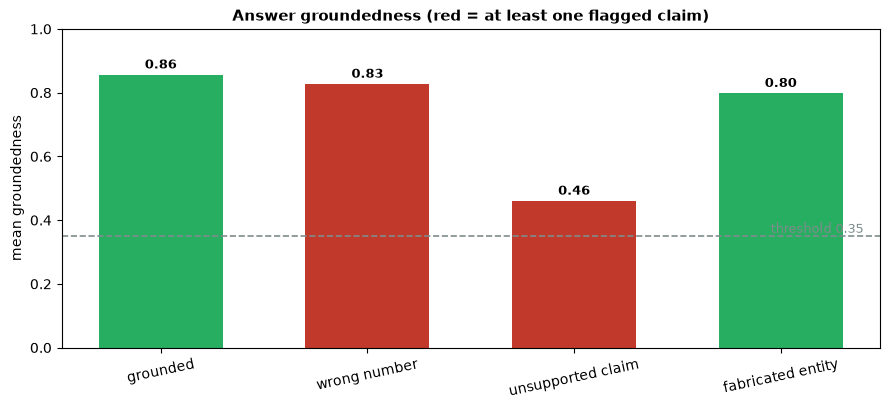

In [5]:
import matplotlib.pyplot as plt
import pandas as pd

rows = []
for s in SAMPLES:
    r = check_answer(s["answer"], s["context"], th)
    rows.append({"label": s["label"], "groundedness": r["groundedness"], "grounded": r["grounded"]})
df = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(9, 4.2))
colors = ["#27ae60" if g else "#c0392b" for g in df["grounded"]]
bars = ax.bar(df["label"], df["groundedness"], color=colors, width=0.6)
ax.axhline(th, ls="--", lw=1.2, color="#7f8c8d")
ax.text(3.4, th+0.01, f"threshold {th}", color="#7f8c8d", fontsize=9, ha="right")
ax.set_ylabel("mean groundedness"); ax.set_ylim(0, 1.0)
ax.set_title("Answer groundedness (red = at least one flagged claim)", fontsize=11, weight="bold")
for b, v in zip(bars, df["groundedness"]):
    ax.text(b.get_x()+b.get_width()/2, v+0.02, f"{v:.2f}", ha="center", fontsize=9, weight="bold")
plt.xticks(rotation=12)
plt.tight_layout()
plt.savefig("groundedness.png", dpi=130, bbox_inches="tight")
plt.show()

## 6. The honest limitation

Notice **`fabricated entity` scored high and passed** - "led by CEO Jane Fairbanks" is bolted onto a sentence that is otherwise fully grounded ("Acme Corp, founded in 2011, makes warehouse robots"), so lexical overlap stays high.

That is the whole point of a lexical screen: it is a **cheap first gate** that reliably catches absent terms and wrong numbers, but it cannot judge entailment. In production you pass flagged **and** borderline answers to a stronger judge (an NLI model or an LLM). The screen's job is to shrink that expensive second pass to the answers that actually need it - not to be the final verdict.

## Try your own

In [6]:
my_context = "The API rate limit is 100 requests per minute. Exceeding it returns HTTP 429."
my_answer  = "The API allows 100 requests per minute; going over returns a 429 error, and limits reset every hour."

r = check_answer(my_answer, my_context, 0.35)
print('groundedness:', r['groundedness'], '| grounded:', r['grounded'])
for c in r['claims']:
    print(('OK  ' if c['grounded'] else 'FLAG'), f"{c['support']:.2f}", c['claim'])
    if not c['grounded']: print('     ->', c['reason'])

groundedness: 0.488 | grounded: True
OK   0.49 The API allows 100 requests per minute; going over returns a 429 error, and limits reset every hour.


---

**Part of [Phoebe's FDE build sprint](https://github.com/phoebefu6/phoebe-the-builder)** - Day 88, LLMOps & GenAI Platform.

Streamlit version (paste context + answer, tune the threshold):
```bash
pip install -r requirements.txt
streamlit run app.py
```